## Data Preparation

This notebook loads the raw bilingual dataset collected from JAMK's Peppi curriculum system, cleans the text, constructs six experimental text configurations, and applies Finnish and English lemmatization.

The outputs feed directly into the embedding generation step in Notebook 2.

### Imports and Setup

In [1]:
import sys
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import spacy

# Version logging for reproducibility. Small changes across spaCy or model versions
# can alter lemmatizer output for Finnish, so these are recorded with each run.
print(f"Python         : {sys.version.split()[0]}")
print(f"pandas         : {pd.__version__}")
print(f"numpy          : {np.__version__}")
print(f"spaCy          : {spacy.__version__}")

nlp_fi = spacy.load("fi_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

print(f"Finnish model  : {nlp_fi.meta['lang']}_{nlp_fi.meta['name']} v{nlp_fi.meta['version']}")
print(f"English model  : {nlp_en.meta['lang']}_{nlp_en.meta['name']} v{nlp_en.meta['version']}")
print(f"Finnish pipe   : {nlp_fi.pipe_names}")
print(f"English pipe   : {nlp_en.pipe_names}")

Python         : 3.10.20
pandas         : 2.3.3
numpy          : 2.2.6
spaCy          : 3.8.14
Finnish model  : fi_core_news_sm v3.8.0
English model  : en_core_web_sm v3.8.0
Finnish pipe   : ['tok2vec', 'tagger', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
English pipe   : ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


### Project Paths

All paths are derived from the notebook's working directory so that the pipeline runs unchanged on any machine. The notebook assumes it is executed either from the project root or from a `notebooks/` subdirectory.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures" / "main"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data     : {RAW_DIR / 'final_dataset.csv'}")
print(f"Processed    : {PROCESSED_DIR}")
print(f"Figures      : {FIGURES_DIR}")

Project root : c:\Users\madee\OneDrive\Desktop\thesis
Raw data     : c:\Users\madee\OneDrive\Desktop\thesis\data\raw\final_dataset.csv
Processed    : c:\Users\madee\OneDrive\Desktop\thesis\data\processed
Figures      : c:\Users\madee\OneDrive\Desktop\thesis\figures\main


### Loading the Dataset

The raw dataset contains 154 manually labelled bilingual course description pairs collected from JAMK's ICT degree programme. Each pair carries a binary similarity label: 1 for equivalent and 0 for non-equivalent.

In [3]:
df = pd.read_csv(RAW_DIR / "final_dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['similarity_label'].value_counts()}")

Shape: (154, 15)

Columns:
['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty']

Label distribution:
similarity_label
1    77
0    77
Name: count, dtype: int64


### Integrity Checks

Three checks are run against the raw dataset before any transformation takes place. Course identifiers must be unique, similarity labels must be strictly binary, and the Finnish columns must carry clearly higher density of Finnish-specific characters (ä and ö) than the English columns. The third check catches column mislabelling that would otherwise propagate silently through the pipeline.

In [4]:
# Check 1: course_id uniqueness
assert df['course_id'].is_unique, "Duplicate course_id values found in dataset"
print(f"course_id uniqueness : OK ({df['course_id'].nunique()} unique rows)")

# Check 2: label domain
assert df['similarity_label'].isin([0, 1]).all(), "similarity_label contains values outside {0, 1}"
print(f"label domain         : OK ({df['similarity_label'].value_counts().to_dict()})")

# Check 3: language sanity via Finnish-specific character density
def fi_char_density(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return sum(1 for c in text.lower() if c in 'äö') / len(text)

fi_density_fi = df['outcomes_fi'].apply(fi_char_density).mean()
fi_density_en = df['outcomes_en'].apply(fi_char_density).mean()

print(f"\nMean ä/ö density in outcomes_fi: {fi_density_fi:.4f}")
print(f"Mean ä/ö density in outcomes_en: {fi_density_en:.4f}")

assert fi_density_fi > 5 * max(fi_density_en, 1e-6), (
    "Language sanity check failed: outcomes_fi does not contain markedly more Finnish-specific "
    "characters than outcomes_en. Possible column mislabelling."
)
print("language sanity      : OK")

course_id uniqueness : OK (154 unique rows)
label domain         : OK ({1: 77, 0: 77})

Mean ä/ö density in outcomes_fi: 0.0411
Mean ä/ö density in outcomes_en: 0.0000
language sanity      : OK


### A Closer Look at the Data

Before any processing begins, it is worth seeing what the raw pairs actually look like. The two examples below show one equivalent pair and one non-equivalent pair from the dataset, giving a concrete sense of what the model will later need to distinguish.

In [5]:
for label in [1, 0]:
    sample = df[df['similarity_label'] == label].iloc[0]
    print(f"Label: {label}")
    print(f"Course ID: {sample['course_id']}")
    print(f"Finnish outcomes: {sample['outcomes_fi'][:300]}")
    print(f"English outcomes: {sample['outcomes_en'][:300]}")
    print("-" * 80)

Label: 1
Course ID: TT00CE07
Finnish outcomes: Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standardisarjan sisällön, rakenteen ja soveltamisalan sekä osaa hyödyntää sitä kyberturvallisuuden hallinn
English outcomes: The student understands the importance, principles and requirements of cyber security and information security management systems in organizations and society. The student knows the content, structure and scope of the ISO/IEC 27000 series of standards and its use in the planning, implementation and 
--------------------------------------------------------------------------------
Label: 0
Course ID: SYN_HARD_TT00CD89_TT00CD82
Finnish outcomes: Opintojakson suoritettuasi ymmärrät ohjelmistojen laadunvarmistuksen ja testauksen merkityksen osana ohjelmistotuotannon prosessia. Tunnet ohjelmistotestauksen tärkeät käsitteet, kuten yk

### Methodological Justification for Text Processing

The processing decisions that follow are grounded in two sources. Virtanen et al. (2019) document the morphological density of Finnish and its implications for token-level representation, which motivates keeping lemmatization as an explicit experimental condition rather than a default transformation. Reimers and Gurevych (2020) show that multilingual sentence embedding models perform best on natural text similar to their training distribution, which motivates keeping preprocessing minimal and restricted to cleaning artifacts rather than aggressive normalization such as stopword removal.

Three specific choices reflect these two considerations:

1. Unicode normalization uses NFC rather than NFD or NFKC. NFC preserves the precomposed Finnish letters ä and ö as single code points that match the expected forms in multilingual tokenizer vocabularies, while decomposed sequences would split each letter from its diacritic and fragment the subword representation.
2. The six-configuration design pairs each raw-text configuration with a lemmatized counterpart built from identical field combinations. This isolates lemmatization as the single experimental factor between configs 1 to 3 and configs 4 to 6.
3. The standalone nan token check uses a word-boundary regex (`\\bnan\\b`) because Finnish contains many tokens with the substring nan, such as nainen and sanan, which a naive substring search would flag as false positives.

### Cleaning the Text Fields

The scraped text contains several artifacts introduced during data collection: bullet point characters, zero-width spaces, soft hyphens, combining diacritics attached to letters, and stray whitespace. These are removed here before any configuration or lemmatization is applied. Missing values in text fields are filled with empty strings to prevent downstream errors.

A per-field summary is printed after cleaning so the effect of each cleaning operation is visible and auditable.

In [6]:
text_columns = [
    'outcomes_fi', 'outcomes_en',
    'contents_fi', 'contents_en',
    'assessment_fi', 'assessment_en',
]

# Artifact classes
BULLET_CLASS = r'[\u2022\u2023\u25E6\u2043\u2219]'
INVISIBLE_CLASS = r'[\u200B\u200C\u200D\u00AD\uFEFF]'

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(BULLET_CLASS, '', text)
    text = re.sub(INVISIBLE_CLASS, '', text)
    # NFC preserves precomposed Finnish letters (ä, ö) while resolving
    # decomposed sequences that would otherwise split a letter from its diacritic
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Pre-cleaning statistics
pre_chars = {col: df[col].fillna("").astype(str).str.len().sum() for col in text_columns}
artifact_counts = {}
for col in text_columns:
    joined = ' '.join(df[col].fillna("").astype(str).tolist())
    artifact_counts[col] = {
        'bullets': len(re.findall(BULLET_CLASS, joined)),
        'invisible': len(re.findall(INVISIBLE_CLASS, joined)),
    }

# Apply cleaning
for col in text_columns:
    df[col] = df[col].apply(clean_text)

# Post-cleaning statistics
post_chars = {col: df[col].str.len().sum() for col in text_columns}

print(f"{'Field':<16} {'Chars before':>14} {'Chars after':>14} {'Bullets':>10} {'Invisible':>10}")
for col in text_columns:
    print(f"{col:<16} {pre_chars[col]:>14} {post_chars[col]:>14} "
          f"{artifact_counts[col]['bullets']:>10} {artifact_counts[col]['invisible']:>10}")

empty_counts = {col: int((df[col] == "").sum()) for col in text_columns}
print(f"\nEmpty fields after cleaning: {empty_counts}")

Field              Chars before    Chars after    Bullets  Invisible
outcomes_fi              120658         120658          0          0
outcomes_en              131496         131472         12          0
contents_fi              121348         121236         56          0
contents_en              128782         128782          0          0
assessment_fi            181830         181776          0          0
assessment_en            203584         203584          0          0

Empty fields after cleaning: {'outcomes_fi': 0, 'outcomes_en': 0, 'contents_fi': 0, 'contents_en': 0, 'assessment_fi': 0, 'assessment_en': 0}


### Building the Six Text Configurations

Each pair is represented in six ways by combining different fields. Configurations 1 to 3 use raw cleaned text. Configurations 4 to 6 repeat the same combinations using lemmatized text, which is produced in the next step. This design allows a direct comparison between raw and lemmatized conditions across identical field combinations.

| Config | Fields included                          | Text type   |
|--------|------------------------------------------|-------------|
| 1      | Outcomes                                 | Raw         |
| 2      | Outcomes + Contents                      | Raw         |
| 3      | Outcomes + Contents + Assessment         | Raw         |
| 4      | Outcomes                                 | Lemmatized  |
| 5      | Outcomes + Contents                      | Lemmatized  |
| 6      | Outcomes + Contents + Assessment         | Lemmatized  |

In [7]:
df['config_1_fi'] = df['outcomes_fi']
df['config_1_en'] = df['outcomes_en']

df['config_2_fi'] = df['outcomes_fi'] + ' ' + df['contents_fi']
df['config_2_en'] = df['outcomes_en'] + ' ' + df['contents_en']

df['config_3_fi'] = df['outcomes_fi'] + ' ' + df['contents_fi'] + ' ' + df['assessment_fi']
df['config_3_en'] = df['outcomes_en'] + ' ' + df['contents_en'] + ' ' + df['assessment_en']

print("Raw configurations built.")
print(f"\nConfig 1 sample (Finnish):\n{df['config_1_fi'].iloc[0][:200]}")
print(f"\nConfig 2 sample (Finnish):\n{df['config_2_fi'].iloc[0][:200]}")
print(f"\nConfig 3 sample (Finnish):\n{df['config_3_fi'].iloc[0][:200]}")

Raw configurations built.

Config 1 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Config 2 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Config 3 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa


### Raw Configurations Checkpoint

The raw-text configurations are saved as a standalone checkpoint before lemmatization. This makes the raw-only dataset directly available to downstream analysis without requiring the full preprocessing pipeline to be re-run.

In [8]:
raw_configs_cols = [
    'course_id', 'title_fi', 'title_en', 'credits',
    'similarity_label', 'label_note', 'label_timestamp',
    'pair_type', 'pair_difficulty',
    'config_1_fi', 'config_1_en',
    'config_2_fi', 'config_2_en',
    'config_3_fi', 'config_3_en',
]

raw_configs_path = PROCESSED_DIR / "dataset_raw_configs.csv"
df[raw_configs_cols].to_csv(raw_configs_path, index=False)

print(f"Raw configurations checkpoint saved to: {raw_configs_path}")
print(f"Shape: ({len(df)}, {len(raw_configs_cols)})")

Raw configurations checkpoint saved to: c:\Users\madee\OneDrive\Desktop\thesis\data\processed\dataset_raw_configs.csv
Shape: (154, 15)


### Applying Lemmatization

Finnish is a morphologically rich language where the same word can appear in dozens of inflected forms (Virtanen et al., 2019). Lemmatization reduces each word to its base form, which can help embedding models treat inflected variants as the same concept. The Finnish pipeline uses spaCy's `fi_core_news_sm` model and the English pipeline uses `en_core_web_sm`. Lemmatization is applied to all six text fields before building configurations 4 to 6.

The implementation uses `nlp.pipe()` with batching rather than per-row `.apply(nlp)` calls. Batching is the canonical spaCy pattern for processing many short texts and reduces overhead substantially. The named-entity recognizer is disabled through the `disable` argument because it is not needed for lemmatization.

In [9]:
def lemmatize_batch(texts, nlp, batch_size=32):
    """Lemmatize a sequence of strings using spaCy's batched pipe.

    Returns a list of lemmatized strings. Empty or non-string inputs
    return an empty string. NER is disabled for speed because it is
    not required for lemmatization.
    """
    input_texts = [t if isinstance(t, str) else "" for t in texts]
    outputs = []
    for doc in nlp.pipe(input_texts, batch_size=batch_size, disable=["ner"]):
        if len(doc) == 0:
            outputs.append("")
        else:
            outputs.append(' '.join(token.lemma_ for token in doc if not token.is_space))
    return outputs

print("Lemmatizing Finnish fields...")
for col in ['outcomes_fi', 'contents_fi', 'assessment_fi']:
    df[col + '_lemma'] = lemmatize_batch(df[col].tolist(), nlp_fi)
    print(f"  {col} done")

print("\nLemmatizing English fields...")
for col in ['outcomes_en', 'contents_en', 'assessment_en']:
    df[col + '_lemma'] = lemmatize_batch(df[col].tolist(), nlp_en)
    print(f"  {col} done")

print("\nLemmatization complete.")
print(f"\nRaw Finnish outcomes (first 200 chars):\n{df['outcomes_fi'].iloc[0][:200]}")
print(f"\nLemmatized Finnish outcomes (first 200 chars):\n{df['outcomes_fi_lemma'].iloc[0][:200]}")

Lemmatizing Finnish fields...
  outcomes_fi done
  contents_fi done
  assessment_fi done

Lemmatizing English fields...
  outcomes_en done
  contents_en done
  assessment_en done

Lemmatization complete.

Raw Finnish outcomes (first 200 chars):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Lemmatized Finnish outcomes (first 200 chars):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl


In [10]:
# Qualitative audit of lemmatization output
print("LEMMATIZATION AUDIT - FINNISH")
print("=" * 80)
for idx in [0, 1, 2, 3, 4]:
    original = df['outcomes_fi'].iloc[idx][:150]
    lemmatized = df['outcomes_fi_lemma'].iloc[idx][:150]
    print(f"\nSample {idx + 1}")
    print(f"  Original:   {original}")
    print(f"  Lemmatized: {lemmatized}")

print("\n\nLEMMATIZATION AUDIT - ENGLISH")
print("=" * 80)
for idx in [0, 1, 2, 3, 4]:
    original = df['outcomes_en'].iloc[idx][:150]
    lemmatized = df['outcomes_en_lemma'].iloc[idx][:150]
    print(f"\nSample {idx + 1}")
    print(f"  Original:   {original}")
    print(f"  Lemmatized: {lemmatized}")

LEMMATIZATION AUDIT - FINNISH

Sample 1
  Original:   Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhtei
  Lemmatized: opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opis

Sample 2
  Original:   Opintojakson suoritettuasi ymmärrät ohjelmistojen laadunvarmistuksen ja testauksen merkityksen osana ohjelmistotuotannon prosessia. Tunnet ohjelmistot
  Lemmatized: Opintojakso suoritettuasi ymmärrä ohjelmisto laadunvarmistus ja testaus merkitys osa ohjelmistotuotanto prosessi . Tunnet ohjelmistotestauknen tärkeä 

Sample 3
  Original:   Regressiomallien avulla voi ennustaa numeerisia arvoja uusille havainnoille. Tutustut erilaisiin regressiomenetelmiin ja osaat vertailla niiden antami
  Lemmatized: Regressiomallien apu voida ennustaa numeerinen arvo uusi havainto . Tutustut erilainen regressiomenet

### Building Lemmatized Configurations

Configurations 4 to 6 mirror the raw configurations exactly, using the same field combinations but with lemmatized text. This produces a clean paired design where the only difference between config 1 and config 4, for example, is whether the text was lemmatized or not.

In [11]:
df['config_4_fi'] = df['outcomes_fi_lemma']
df['config_4_en'] = df['outcomes_en_lemma']

df['config_5_fi'] = df['outcomes_fi_lemma'] + ' ' + df['contents_fi_lemma']
df['config_5_en'] = df['outcomes_en_lemma'] + ' ' + df['contents_en_lemma']

df['config_6_fi'] = df['outcomes_fi_lemma'] + ' ' + df['contents_fi_lemma'] + ' ' + df['assessment_fi_lemma']
df['config_6_en'] = df['outcomes_en_lemma'] + ' ' + df['contents_en_lemma'] + ' ' + df['assessment_en_lemma']

print("Lemmatized configurations built.")
print(f"\nConfig 4 sample (Finnish):\n{df['config_4_fi'].iloc[0][:200]}")
print(f"\nConfig 5 sample (Finnish):\n{df['config_5_fi'].iloc[0][:200]}")
print(f"\nConfig 6 sample (Finnish):\n{df['config_6_fi'].iloc[0][:200]}")

Lemmatized configurations built.

Config 4 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl

Config 5 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl

Config 6 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl


### Verification Checks

Two assertions are run across all twelve configuration columns. The first confirms no standalone nan token appears, which can be introduced when missing fields are concatenated as strings. The second confirms no configuration column is empty for any row. Both assertions must pass before the data moves to the next stage, and execution halts immediately if either fails.

In [12]:
config_columns = [f'config_{i}_{lang}' for i in range(1, 7) for lang in ('fi', 'en')]

# Standalone nan tokens across all configuration columns
nan_counts = {}
for col in config_columns:
    mask = df[col].astype(str).apply(lambda x: bool(re.search(r'\bnan\b', x)))
    nan_counts[col] = int(mask.sum())

assert all(c == 0 for c in nan_counts.values()), (
    f"Standalone nan tokens detected: {[(k, v) for k, v in nan_counts.items() if v > 0]}"
)
print("No standalone nan tokens in any configuration column.")

# Empty configuration cells
empty_counts = {col: int((df[col].str.strip() == '').sum()) for col in config_columns}
assert all(c == 0 for c in empty_counts.values()), (
    f"Empty configuration cells detected: {[(k, v) for k, v in empty_counts.items() if v > 0]}"
)
print("No empty configuration cells in any configuration column.")
print("\nAll verification checks passed.")

No standalone nan tokens in any configuration column.
No empty configuration cells in any configuration column.

All verification checks passed.


### Text Length Distribution (Words)

Longer configurations naturally contain more text, which affects how much information is available to the embedding model. The chart below shows the average word count per configuration for Finnish and English separately.

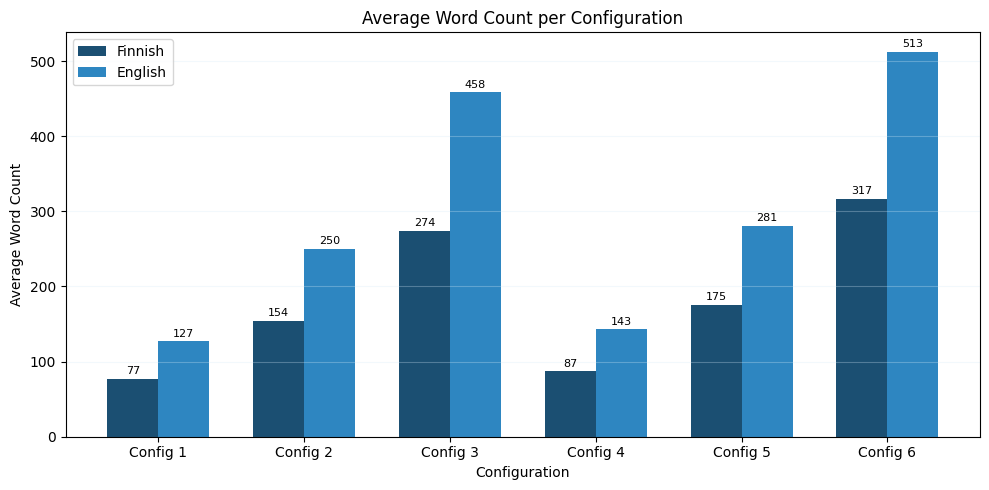

Plot saved.


In [13]:
import matplotlib.pyplot as plt

PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'

fi_means = [df[f'config_{i}_fi'].apply(lambda x: len(x.split())).mean() for i in range(1, 7)]
en_means = [df[f'config_{i}_en'].apply(lambda x: len(x.split())).mean() for i in range(1, 7)]
configs = [f'Config {i}' for i in range(1, 7)]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_fi = ax.bar(x - width/2, fi_means, width, label='Finnish', color=PRIMARY)
bars_en = ax.bar(x + width/2, en_means, width, label='English', color=SECONDARY)

ax.set_xlabel('Configuration')
ax.set_ylabel('Average Word Count')
ax.set_title('Average Word Count per Configuration')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
ax.grid(axis='y', alpha=0.3, color='#D6EAF8')

ax.bar_label(bars_fi, fmt='%.0f', padding=2, fontsize=8)
ax.bar_label(bars_en, fmt='%.0f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "config_word_counts.png", dpi=150)
plt.show()
print("Plot saved.")

### Text Length Distribution (Subword Tokens)

Word count is only a rough proxy for the amount of text a transformer model actually processes. Sentence embedding models operate on subword tokens, and Finnish inflected forms frequently expand to several subword tokens each (Virtanen et al., 2019). Because all five embedding models used in this thesis have a maximum input length of 512 tokens, tokenizer-aware length analysis is necessary to understand the truncation risk for each configuration.

Three tokenizers are used, covering the three tokenization families present in the model set: LaBSE (BERT WordPiece, multilingual vocabulary), multilingual MPNet (XLM-R SentencePiece, also used by stsb-xlm-r and multilingual-e5), and FinBERT (BERT WordPiece, Finnish-only vocabulary). Together these characterise the tokenization behaviour of all five models evaluated in Notebook 2.

Loaded tokenizer: LaBSE
Loaded tokenizer: mpnet-multilingual
Loaded tokenizer: FinBERT


Token indices sequence length is longer than the specified maximum sequence length for this model (674 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (627 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (554 > 512). Running this sequence through the model will result in indexing errors



Subword token statistics per configuration:
         tokenizer   config language  mean_tokens  median_tokens  max_tokens  pct_over_512
             LaBSE Config 1       FI   187.896104          172.0         471      0.000000
             LaBSE Config 1       EN   150.292208          140.0         410      0.000000
             LaBSE Config 2       FI   374.454545          342.0         712     11.688312
             LaBSE Config 2       EN   295.305195          274.0         618      3.246753
             LaBSE Config 3       FI   646.902597          624.0        1089     76.623377
             LaBSE Config 3       EN   536.961039          509.0         941     48.701299
             LaBSE Config 4       FI   177.584416          158.0         435      0.000000
             LaBSE Config 4       EN   149.558442          141.0         401      0.000000
             LaBSE Config 5       FI   351.766234          323.0         654      9.740260
             LaBSE Config 5       EN   292.86

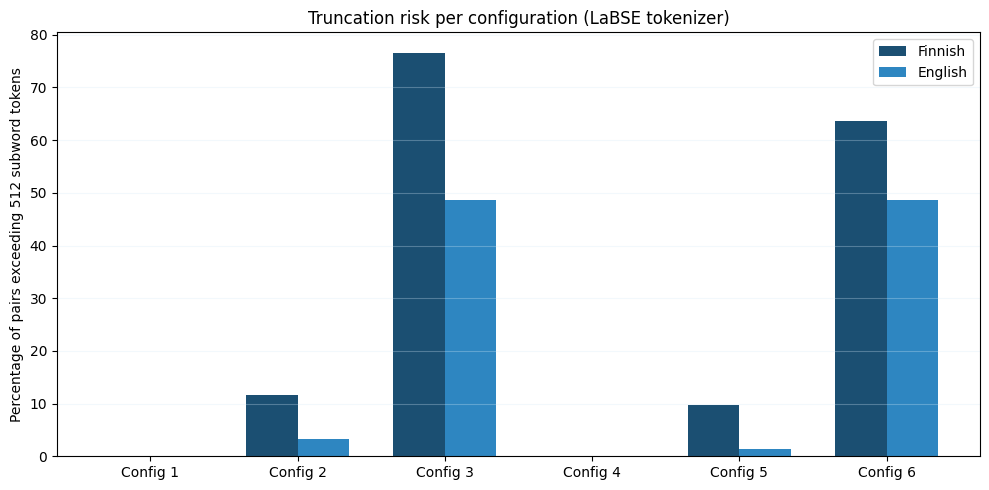


Plot saved.
Token statistics saved to: c:\Users\madee\OneDrive\Desktop\thesis\data\processed\token_statistics.csv


In [14]:
try:
    from transformers import AutoTokenizer

    TOKENIZER_SPECS = {
        "LaBSE": "sentence-transformers/LaBSE",
        "mpnet-multilingual": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
        "FinBERT": "TurkuNLP/bert-base-finnish-cased-v1",
    }

    tokenizers = {}
    for name, spec in TOKENIZER_SPECS.items():
        tokenizers[name] = AutoTokenizer.from_pretrained(spec)
        print(f"Loaded tokenizer: {name}")

    rows = []
    for tok_name, tok in tokenizers.items():
        for i in range(1, 7):
            for lang in ('fi', 'en'):
                col = f'config_{i}_{lang}'
                counts = np.array([
                    len(tok.encode(t, add_special_tokens=True)) for t in df[col]
                ])
                rows.append({
                    'tokenizer': tok_name,
                    'config': f'Config {i}',
                    'language': lang.upper(),
                    'mean_tokens': float(counts.mean()),
                    'median_tokens': float(np.median(counts)),
                    'max_tokens': int(counts.max()),
                    'pct_over_512': float(100 * (counts > 512).mean()),
                })

    token_stats = pd.DataFrame(rows)
    print("\nSubword token statistics per configuration:")
    print(token_stats.to_string(index=False))

    # Truncation risk plot for LaBSE
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = token_stats[token_stats['tokenizer'] == 'LaBSE']
    configs_list = sub['config'].unique().tolist()
    xpos = np.arange(len(configs_list))
    fi_vals = sub[sub['language'] == 'FI']['pct_over_512'].values
    en_vals = sub[sub['language'] == 'EN']['pct_over_512'].values

    ax.bar(xpos - width/2, fi_vals, width, label='Finnish', color=PRIMARY)
    ax.bar(xpos + width/2, en_vals, width, label='English', color=SECONDARY)
    ax.set_xticks(xpos)
    ax.set_xticklabels(configs_list)
    ax.set_ylabel('Percentage of pairs exceeding 512 subword tokens')
    ax.set_title('Truncation risk per configuration (LaBSE tokenizer)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3, color='#D6EAF8')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "config_token_truncation.png", dpi=150)
    plt.show()
    print("\nPlot saved.")

    token_stats.to_csv(PROCESSED_DIR / "token_statistics.csv", index=False)
    print(f"Token statistics saved to: {PROCESSED_DIR / 'token_statistics.csv'}")

except Exception as e:
    print(f"Tokenizer-aware analysis skipped ({type(e).__name__}: {e}).")
    print("This step requires the transformers library and cached tokenizer files.")

English descriptions are consistently longer than Finnish in word count across all configurations, reflecting Finnish morphological density where inflected forms compress meaning into fewer words. Once texts are expressed in subword tokens, however, the gap narrows considerably because Finnish inflected forms expand into multiple subword pieces.

Configurations 3 and 6 are the most affected by the 512-token input limit. This truncation characteristic is examined in further detail in Notebook 5, and is treated explicitly as a known limitation in the methodology chapter.

### Saving the Preprocessed Dataset

The full cleaned and configured dataset is saved to the processed data folder. This file serves as the single input to Notebook 2, ensuring that embedding generation always starts from the same verified and reproducible state.

In [15]:
output_path = PROCESSED_DIR / "dataset_preprocessed.csv"
df.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"\nColumns saved:\n{df.columns.tolist()}")

Dataset saved to: c:\Users\madee\OneDrive\Desktop\thesis\data\processed\dataset_preprocessed.csv
Shape: (154, 33)

Columns saved:
['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty', 'config_1_fi', 'config_1_en', 'config_2_fi', 'config_2_en', 'config_3_fi', 'config_3_en', 'outcomes_fi_lemma', 'contents_fi_lemma', 'assessment_fi_lemma', 'outcomes_en_lemma', 'contents_en_lemma', 'assessment_en_lemma', 'config_4_fi', 'config_4_en', 'config_5_fi', 'config_5_en', 'config_6_fi', 'config_6_en']


### Summary

This notebook produced a fully cleaned and configured dataset ready for embedding generation. Starting from 154 raw bilingual course description pairs, the pipeline verified dataset integrity, removed scraper artifacts, applied NFC normalization to preserve Finnish characters, built six text configurations combining outcomes, contents, and assessment fields, and applied spaCy lemmatization for both Finnish and English using batched processing.

All verification assertions passed: no duplicate course identifiers, no label violations, no language mislabelling, no standalone nan tokens, and no empty configuration cells. Two output files were written to `data/processed/`: `dataset_raw_configs.csv` as a raw-only checkpoint and `dataset_preprocessed.csv` as the full preprocessed dataset feeding Notebook 2.